# YouTube Comment Sentiment Analysis — DistilBERT Fine-Tuning
**3-class classifier (Positive / Neutral / Negative) · Full fine-tuning · Google Colab + Drive**

In [1]:
import time
start_time = time.time()

## Step 1 — Environment Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q datasets transformers accelerate evaluate scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [4]:
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset, DatasetDict, load_from_disk
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)
import evaluate

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [5]:
# Project paths (Google Drive)
PROJECT_PATH = "/content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/"
os.makedirs(PROJECT_PATH, exist_ok=True)

RAW_DATA = PROJECT_PATH + "raw_data/"
PROCESSED_DATA = PROJECT_PATH + "processed_data/"
MODEL_CHECKPOINTS = PROJECT_PATH + "model_checkpoints/"
FINAL_MODEL = PROJECT_PATH + "final_model/"
OUTPUTS = PROJECT_PATH + "outputs/"

for p in [RAW_DATA, PROCESSED_DATA, MODEL_CHECKPOINTS, FINAL_MODEL, OUTPUTS]:
    os.makedirs(p, exist_ok=True)
print("Project directories ready.")

Project directories ready.


## Step 2 — Data Import

In [6]:
raw_dataset = load_dataset("AmaanP314/youtube-comment-sentiment")
print(raw_dataset)
print(raw_dataset["train"][0])

README.md: 0.00B [00:00, ?B/s]

youtube-comments-sentiment.csv:   0%|          | 0.00/296M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1032225 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID', 'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt', 'CountryCode', 'CategoryID'],
        num_rows: 1032225
    })
})
{'CommentID': 'UgyRjrEdJIPrf68uND14AaABAg', 'VideoID': 'mcY4M9gjtsI', 'VideoTitle': 'They killed my friend.#tales #movie #shorts', 'AuthorName': '@OneWhoWandered', 'AuthorChannelID': 'UC_-UEXaBL1dqqUPGkDll49A', 'CommentText': 'Anyone know what movie this is?', 'Sentiment': 'Neutral', 'Likes': 0, 'Replies': 2, 'PublishedAt': '2025-01-15 00:54:55', 'CountryCode': 'NZ', 'CategoryID': 1}


In [7]:
# Cache raw data to Drive for resumability
raw_dataset.save_to_disk(RAW_DATA)
print(f"Raw data saved to {RAW_DATA}")

Saving the dataset (0/1 shards):   0%|          | 0/1032225 [00:00<?, ? examples/s]

Raw data saved to /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/raw_data/


## Step 3 — Data Cleaning

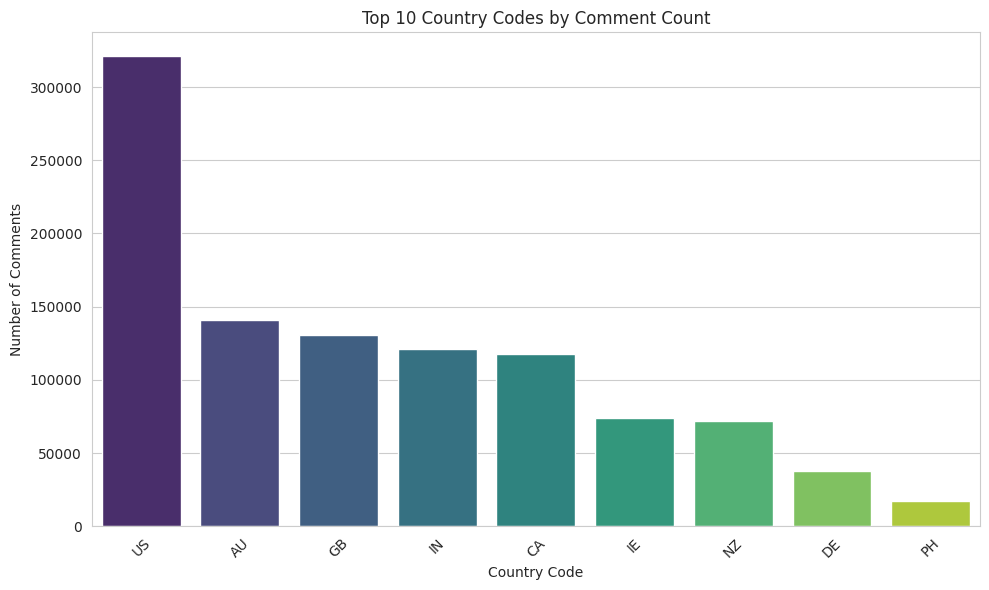

Top 10 Country Codes by Comment Count:
CountryCode
US    321268
AU    141119
GB    130382
IN    121246
CA    117880
IE     73884
NZ     71668
DE     37648
PH     17130
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the raw_dataset's train split to a pandas DataFrame
df_country_code = raw_dataset["train"].to_pandas()

# Visualize data size by 'CountryCode'
country_counts = df_country_code['CountryCode'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.title('Top 10 Country Codes by Comment Count')
plt.xlabel('Country Code')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 Country Codes by Comment Count:")
print(country_counts)


In [9]:
# Keep only English Comments
english_speaking_countries = ['US', 'AU', 'GB', 'NZ']
eng_dataset = raw_dataset.filter(lambda example: example['CountryCode'] in english_speaking_countries)


Filter:   0%|          | 0/1032225 [00:00<?, ? examples/s]

In [10]:
df = eng_dataset["train"].to_pandas()
initial_len = len(df)
print(f"Initial rows: {initial_len:,}")

# Keep only needed columns
df = df[["CommentText", "Sentiment"]].copy()

# Remove duplicates
df.drop_duplicates(subset="CommentText", keep="first", inplace=True)
print(f"After dedup: {len(df):,} (removed {initial_len - len(df):,})")

# Remove URLs and links
url_pattern = r'\b(?:https?|ftp|file|mailto):\/\/\S+|(?:www\.)\S+\.\S+\b'
df["CommentText"] = df["CommentText"].astype(str).apply(lambda x: re.sub(url_pattern, '', x))

# Remove timestamps (e.g., 2:30, 01:23:45)
df["CommentText"] = df["CommentText"].apply(lambda x: re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', x))

# Normalize whitespace
df["CommentText"] = df["CommentText"].str.strip().apply(lambda x: re.sub(r'\s+', ' ', x))

# Remove empty or very short comments (< 3 chars)
df = df[df["CommentText"].str.len() >= 3].reset_index(drop=True)
print(f"After cleaning: {len(df):,} (total removed: {initial_len - len(df):,})")
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")

# Save cleaned dataframe as CSV
df.to_csv(OUTPUTS + "cleaned_comments.csv", index=False)
print(f"Cleaned data saved → {OUTPUTS}cleaned_comments.csv  ({len(df):,} rows)")

Initial rows: 664,437
After dedup: 642,050 (removed 22,387)
After cleaning: 639,572 (total removed: 24,865)

Sentiment distribution:
Sentiment
Negative    230323
Neutral     205488
Positive    203761
Name: count, dtype: int64
Cleaned data saved → /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/outputs/cleaned_comments.csv  (639,572 rows)


## Step 4 — Exploratory Data Analysis (EDA)

In [11]:
# Load cleaned dataframe from CSV
df_cleaned = pd.read_csv(OUTPUTS + "cleaned_comments.csv")
print(f"Cleaned data loaded from {OUTPUTS}cleaned_comments.csv ({len(df_cleaned):,} rows)")
print("\nFirst 5 rows of the loaded 'df_cleaned':")
print(df_cleaned.head())

# Create a copy for EDA to preserve the original cleaned state
df = df_cleaned.copy()
print(f"'df' created with {len(df):,} rows for further analysis.")
print("\nFirst 5 rows of the loaded 'df':")
print(df.head())


Cleaned data loaded from /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/outputs/cleaned_comments.csv (639,572 rows)

First 5 rows of the loaded 'df_cleaned':
                                         CommentText Sentiment
0                    Anyone know what movie this is?   Neutral
1  The fact they're holding each other back while...  Positive
2  Thanks for the great video. I don't understand...   Neutral
3  Good person helping good people. This is how i...  Positive
4                                   Dei løk de seim😂   Neutral
'df' created with 639,572 rows for further analysis.

First 5 rows of the loaded 'df':
                                         CommentText Sentiment
0                    Anyone know what movie this is?   Neutral
1  The fact they're holding each other back while...  Positive
2  Thanks for the great video. I don't understand...   Neutral
3  Good person helping good people. This is how i...  Positive
4                                 

In [12]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
MAX_LENGTH = 128

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

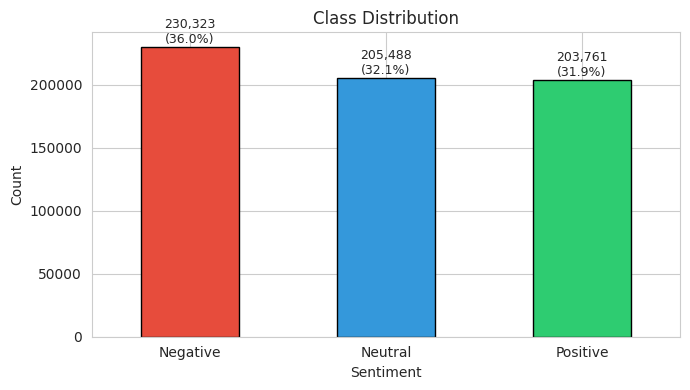

In [13]:
# Class distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df["Sentiment"].value_counts()
colors = {"Positive": "#2ecc71", "Neutral": "#3498db", "Negative": "#e74c3c"}
counts.plot(kind="bar", color=[colors[c] for c in counts.index], ax=ax, edgecolor="black")
for i, (v, pct) in enumerate(zip(counts.values, counts.values / len(df) * 100)):
    ax.text(i, v + len(df)*0.005, f"{v:,}\n({pct:.1f}%)", ha="center", fontsize=9)
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
ax.set_xticklabels(counts.index, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUTS + "class_distribution.png", dpi=150)
plt.show()

Token indices sequence length is longer than the specified maximum sequence length for this model (637 > 512). Running this sequence through the model will result in indexing errors


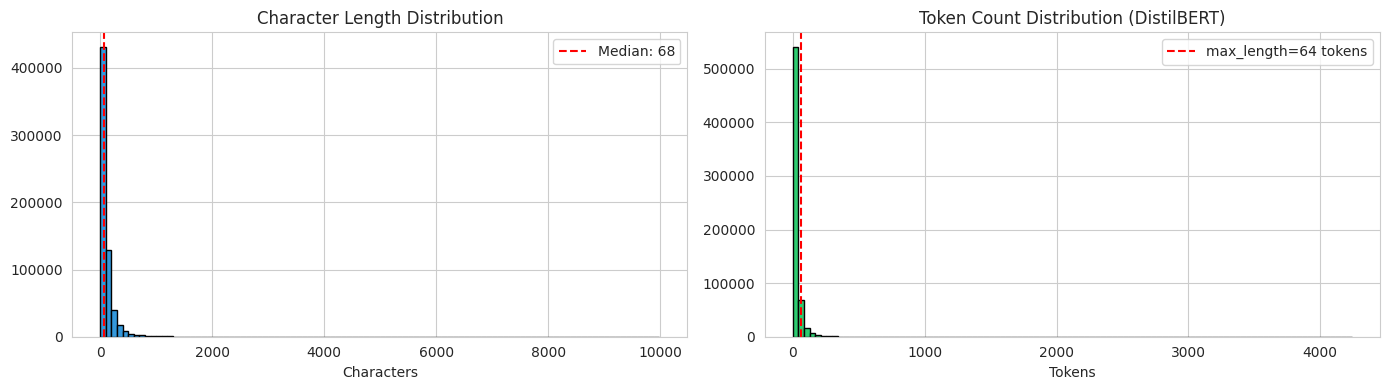

                count        mean         std  min   25%   50%    75%     max
char_len     639572.0  112.771547  181.516642  3.0  37.0  68.0  126.0  9985.0
token_count  639572.0   27.614772   46.478417  0.0   9.0  17.0   31.0  4242.0


In [14]:
# Comment length distribution (characters)
df["char_len"] = df["CommentText"].str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["char_len"].hist(bins=100, ax=axes[0], color="#3498db", edgecolor="black")
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].axvline(df["char_len"].median(), color="red", linestyle="--", label=f'Median: {df["char_len"].median():.0f}')
axes[0].legend()

# Token count distribution (quick estimate using whitespace split)
# df["word_count"] = df["CommentText"].str.split().str.len()
# df["word_count"].hist(bins=100, ax=axes[1], color="#2ecc71", edgecolor="black")
# axes[1].set_title("Word Count Distribution")
# axes[1].set_xlabel("Words")
df["token_count"] = df["CommentText"].apply(lambda x: len(tokenizer.tokenize(x)))
df["token_count"].hist(bins=100, ax=axes[1], color="#2ecc71", edgecolor="black")
axes[1].set_title("Token Count Distribution (DistilBERT)")
axes[1].set_xlabel("Tokens")
axes[1].axvline(64, color="red", linestyle="--", label="max_length=64 tokens")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS + "length_distribution.png", dpi=150)
plt.show()

# stats = df[["char_len", "word_count"]].describe().T
stats = df[["char_len", "token_count"]].describe().T
stats.to_csv(OUTPUTS + "dataset_stats.csv")
print(stats)
# df.drop(columns=["char_len", "word_count"], inplace=True)
# df.drop(columns=["char_len", "token_count"], inplace=True)


In [15]:
# Sample comments per class
samples = df.groupby("Sentiment").apply(lambda x: x.sample(5, random_state=SEED)).reset_index(drop=True)
samples.to_csv(OUTPUTS + "sample_comments.csv", index=False)
for sentiment in ["Positive", "Neutral", "Negative"]:
    print(f"\n--- {sentiment} ---")
    for _, row in samples[samples["Sentiment"] == sentiment].iterrows():
        print(f"  {row['CommentText'][:120]}")


--- Positive ---
  Exactly how this game is 😂 👏 it goes from Goofy fun times surviving and traveling together to find vehicles or objective
  Awesomely awesome
  😅🫸🫸🫸😍😍😍😍😍😍😍😍😍😍😍😍🥰💝💝💝🤭😘
  Kids over 16 riding bikes acting hard is just fucking hilarious 😂
  He was so confused😂

--- Neutral ---
  Imagine bro buys real madrid☠️
  "You run on tampons. we'll run on workers' rights"
  This is barrel racing.
  Looking again at this in 2022, Even more relevant in today's Geopolitical environment. Cheers from Michael. Australia.
  Maybe Honda can make a diesel version of the Zero?

--- Negative ---
  Instead of him having to deal with 🐱 smelling like fish the ladies are gonna have to deal with his 🍆 smelling like fish
  I hope it helps the Democrats, anything to help keep control of the country out of the hands of the fascist, but I hope 
  People siding with cyclists... I hope you all never have to experience why it is important to be considerate of others' 
  A simple man for even simpler peop

In [16]:
# Save EDA dataframe as CSV
df.to_csv(OUTPUTS + "eda_comments.csv", index=False)
print(f"EDA data saved → {OUTPUTS}eda_comments.csv  ({len(df):,} rows)")

EDA data saved → /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/outputs/eda_comments.csv  (639,572 rows)


## Step 5 — Data Preprocessing & Tokenization

In [17]:
# Load cleaned dataframe from CSV
df_eda = pd.read_csv(OUTPUTS + "eda_comments.csv")
print(f"EDA data loaded from {OUTPUTS}eda_comments.csv ({len(df_eda):,} rows)")
print("\nFirst 5 rows of the loaded 'df_eda':")
print(df_eda.head())

# Create a copy for EDA to preserve the original cleaned state
df = df_eda.copy()
print(f"'df' created with {len(df):,} rows for further analysis.")
print("\nFirst 5 rows of the loaded 'df':")
print(df.head())


EDA data loaded from /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/outputs/eda_comments.csv (639,572 rows)

First 5 rows of the loaded 'df_eda':
                                         CommentText Sentiment  char_len  \
0                    Anyone know what movie this is?   Neutral        31   
1  The fact they're holding each other back while...  Positive        79   
2  Thanks for the great video. I don't understand...   Neutral       486   
3  Good person helping good people. This is how i...  Positive        94   
4                                   Dei løk de seim😂   Neutral        16   

   token_count  
0            7  
1           15  
2          111  
3           21  
4            6  
'df' created with 639,572 rows for further analysis.

First 5 rows of the loaded 'df':
                                         CommentText Sentiment  char_len  \
0                    Anyone know what movie this is?   Neutral        31   
1  The fact they're holding 

In [18]:
print(df.columns.tolist())

# Label encoding: Positive→0, Neutral→1, Negative→2
LABEL_MAP = {"Positive": 0, "Neutral": 1, "Negative": 2}
ID2LABEL = {v: k for k, v in LABEL_MAP.items()}

df["label"] = df["Sentiment"].map(LABEL_MAP)
df.rename(columns={"CommentText": "text"}, inplace=True)
df_standby = df
df = df[["text", "label", "token_count"]].copy()

print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")
print(f"\nTotal samples: {len(df):,}")

['CommentText', 'Sentiment', 'char_len', 'token_count']
Label distribution:
label
0    203761
1    205488
2    230323
Name: count, dtype: int64

Total samples: 639,572


In [19]:
print(f"Total samples: {len(df):,}")
before = len(df)
print(f"Total before : {before}")

Total samples: 639,572
Total before : 639572


In [20]:
# Filter out comments exceeding MAX_LENGTH tokens
# before = len(df)
df = df[df["token_count"] <= MAX_LENGTH].reset_index(drop=True)
print(f"After token filter (≤{MAX_LENGTH}): {len(df):,} (removed {before - len(df):,})")
# df.drop(columns=["char_len", "token_count"], inplace=True)
df.drop(columns=["token_count"], inplace=True)

After token filter (≤128): 625,882 (removed 13,690)


In [21]:
print(f"\nLabel distribution after filtering:\n{df['label'].value_counts().sort_index()}")
print(f"\nTotal samples: {len(df):,}")


Label distribution after filtering:
label
0    199953
1    201986
2    223943
Name: count, dtype: int64

Total samples: 625,882


In [22]:
# Stratified sampling: 50,000 samples for each sentiment label
sampled_dfs = []
for label_val in df['label'].unique():
    n_samples = min(100000, len(df[df['label'] == label_val]))
    sampled_dfs.append(df[df['label'] == label_val].sample(n=n_samples, random_state=SEED))

df_chosen = pd.concat(sampled_dfs).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Created 'df_chosen' with {len(df_chosen):,} rows after stratified sampling.")
print(f"Label distribution in 'df_chosen':\n{df_chosen['label'].value_counts().sort_index()}")

# Save the chosen dataset to CSV
df_chosen.to_csv(OUTPUTS + "chosen_dataset_100000.csv", index=False)
print(f"Chosen dataset saved → {OUTPUTS}chosen_dataset_100000.csv  ({len(df_chosen):,} rows)")


Created 'df_chosen' with 300,000 rows after stratified sampling.
Label distribution in 'df_chosen':
label
0    100000
1    100000
2    100000
Name: count, dtype: int64
Chosen dataset saved → /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/outputs/chosen_dataset_100000.csv  (300,000 rows)


In [23]:
# Load cleaned dataframe from CSV
df_chosen = pd.read_csv(OUTPUTS + "chosen_dataset_100000.csv")
print(f"'df_chosen' created with {len(df_chosen):,} rows for further analysis.")
print(df_chosen.head())

# Create a copy to preserve the original state
df = df_chosen.copy()
print(f"'df' updated with {len(df):,} rows for subsequent splitting.")
print(df.head())


'df_chosen' created with 300,000 rows for further analysis.
                                                text  label
0            Name of the Movie: That's my Boy (2012)      1
1                                                Yow      1
2  "Joel where have you been? That's what you guy...      0
3                           I couldn't care less 🤣🤣🤣      2
4  I watch often when this Mann help dogs, He's f...      0
'df' updated with 300,000 rows for subsequent splitting.
                                                text  label
0            Name of the Movie: That's my Boy (2012)      1
1                                                Yow      1
2  "Joel where have you been? That's what you guy...      0
3                           I couldn't care less 🤣🤣🤣      2
4  I watch often when this Mann help dogs, He's f...      0


In [24]:
# Stratified split: 80% train / 10% val / 10% test
from datasets import Dataset
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

print(f"Train: {len(dataset['train']):,}  |  Val: {len(dataset['validation']):,}  |  Test: {len(dataset['test']):,}")

Train: 240,000  |  Val: 30,000  |  Test: 30,000


In [25]:
# Tokenize

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = dataset.map(tokenize_fn, batched=True, batch_size=1000)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization complete.")
print(tokenized_dataset)

Map:   0%|          | 0/240000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Tokenization complete.
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 240000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 30000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 30000
    })
})


In [26]:
# Save tokenized dataset to Drive
tokenized_dataset.save_to_disk(PROCESSED_DATA)
print(f"Processed data saved to {PROCESSED_DATA}")

Saving the dataset (0/1 shards):   0%|          | 0/240000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/30000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/30000 [00:00<?, ? examples/s]

Processed data saved to /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/processed_data/


## Step 6 — Model Import

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
!pip install -q evaluate

In [29]:
import os
import json
import torch
import evaluate
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import (
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import load_from_disk


In [30]:
# Define device for model placement
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Label encoding: Positive→0, Neutral→1, Negative→2
LABEL_MAP = {"Positive": 0, "Neutral": 1, "Negative": 2}
ID2LABEL = {v: k for k, v in LABEL_MAP.items()}


In [31]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL_MAP,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}  |  Trainable: {trainable_params:,}  |  All trainable: {total_params == trainable_params}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 66,955,779  |  Trainable: 66,955,779  |  All trainable: True


## Step 7 — Fine-Tuning

In [32]:
# Project paths (Google Drive)
PROJECT_PATH = "/content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/"
RAW_DATA = PROJECT_PATH + "raw_data/"
PROCESSED_DATA = PROJECT_PATH + "processed_data/"
MODEL_CHECKPOINTS = PROJECT_PATH + "model_checkpoints/"
FINAL_MODEL = PROJECT_PATH + "final_model/"
OUTPUTS = PROJECT_PATH + "outputs/"
SEED = 42


In [33]:
# Load tokenized dataset from Drive
tokenized_dataset = load_from_disk(PROCESSED_DATA)
print(f"Tokenized dataset loaded from {PROCESSED_DATA}")
print(tokenized_dataset)


Tokenized dataset loaded from /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/processed_data/
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 240000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 30000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 30000
    })
})


In [34]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}

In [36]:
training_args = TrainingArguments(
    output_dir=MODEL_CHECKPOINTS,
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    gradient_accumulation_steps=2,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    label_smoothing_factor=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    # eval_steps=500,
    save_strategy="epoch",
    # save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
)

print("Training configuration ready. Starting training...")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration ready. Starting training...


In [37]:
# Resume from checkpoint if available, otherwise start fresh
import glob
checkpoints = glob.glob(os.path.join(MODEL_CHECKPOINTS, "checkpoint-*"))
resume_ckpt = max(checkpoints, key=os.path.getmtime) if checkpoints else None
if resume_ckpt:
    print(f"Resuming from: {resume_ckpt}")


In [38]:
# Train
trainer.train(resume_from_checkpoint=resume_ckpt)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.570925,0.765260,0.709933,0.710077
2,1.464080,0.747039,0.721433,0.722298
3,1.339746,0.755757,0.722433,0.722864
4,1.232008,0.771813,0.722667,0.723521
5,1.178529,0.780765,0.721833,0.722144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=9375, training_loss=1.3842362027994792, metrics={'train_runtime': 3246.1185, 'train_samples_per_second': 369.672, 'train_steps_per_second': 2.888, 'total_flos': 3.97409283072e+16, 'train_loss': 1.3842362027994792, 'epoch': 5.0})

## Step 8 — Model Evaluation

In [39]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

In [40]:
# Predict on test set
predictions = trainer.predict(tokenized_dataset["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Metrics
acc = accuracy_score(labels, preds)
macro_f1 = f1_score(labels, preds, average="macro")
macro_prec = precision_score(labels, preds, average="macro")
macro_rec = recall_score(labels, preds, average="macro")

metrics = {
    "accuracy": round(acc, 4),
    "macro_f1": round(macro_f1, 4),
    "macro_precision": round(macro_prec, 4),
    "macro_recall": round(macro_rec, 4),
}
print("=== Test Set Results ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")

with open(OUTPUTS + "test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

=== Test Set Results ===
  accuracy: 0.7256
  macro_f1: 0.7264
  macro_precision: 0.7283
  macro_recall: 0.7256


In [41]:
# Classification report
label_names = ["Positive", "Neutral", "Negative"]
report = classification_report(labels, preds, target_names=label_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(OUTPUTS + "classification_report.csv")
print(classification_report(labels, preds, target_names=label_names))

              precision    recall  f1-score   support

    Positive       0.78      0.75      0.76     10000
     Neutral       0.66      0.71      0.69     10000
    Negative       0.74      0.72      0.73     10000

    accuracy                           0.73     30000
   macro avg       0.73      0.73      0.73     30000
weighted avg       0.73      0.73      0.73     30000



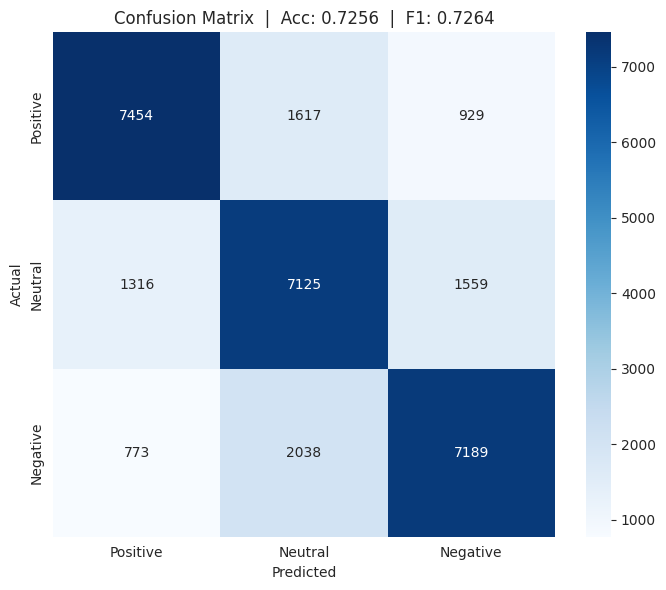

In [42]:
# Confusion matrix
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix  |  Acc: {acc:.4f}  |  F1: {macro_f1:.4f}")
plt.tight_layout()
plt.savefig(OUTPUTS + "confusion_matrix.png", dpi=150)
plt.show()

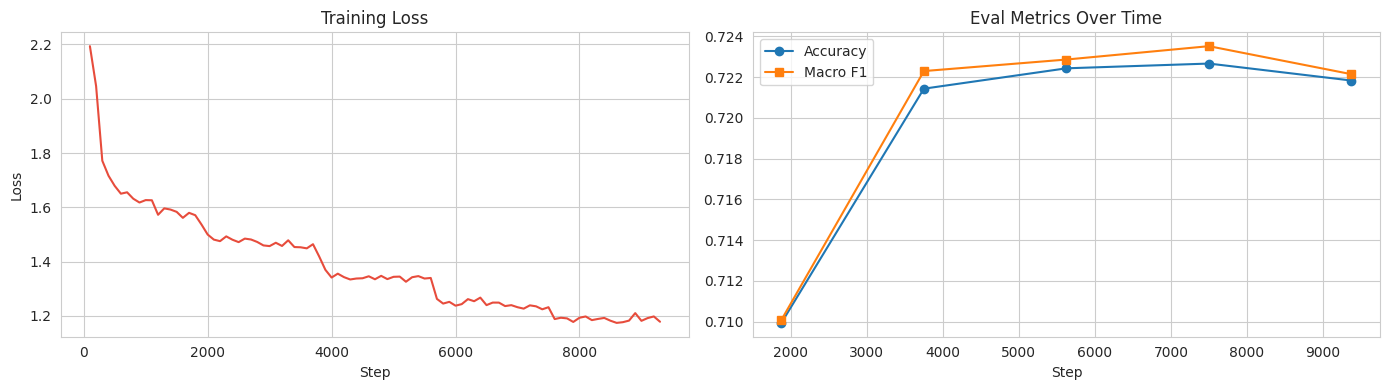

In [43]:
# Training loss & eval metric curves
log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs = [x for x in log_history if "eval_f1" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if train_logs:
    axes[0].plot([x["step"] for x in train_logs], [x["loss"] for x in train_logs], color="#e74c3c")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")

if eval_logs:
    axes[1].plot([x["step"] for x in eval_logs], [x["eval_accuracy"] for x in eval_logs], label="Accuracy", marker="o")
    axes[1].plot([x["step"] for x in eval_logs], [x["eval_f1"] for x in eval_logs], label="Macro F1", marker="s")
    axes[1].set_title("Eval Metrics Over Time")
    axes[1].set_xlabel("Step")
    axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS + "training_curves.png", dpi=150)
plt.show()

## Step 9 — Save Final Model

In [44]:
import os
from transformers import DistilBertTokenizer

# Ensure tokenizer is defined. This handles cases where earlier cells might not have run (e.g., kernel restart).
if 'tokenizer' not in globals() or not isinstance(tokenizer, DistilBertTokenizer):
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

model.save_pretrained(FINAL_MODEL)
tokenizer.save_pretrained(FINAL_MODEL)

saved_files = os.listdir(FINAL_MODEL)
model_size_mb = sum(os.path.getsize(os.path.join(FINAL_MODEL, f)) for f in saved_files) / 1e6
print(f"Model saved to {FINAL_MODEL}")
print(f"Files: {saved_files}")
print(f"Total size: {model_size_mb:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/final_model/
Files: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']
Total size: 268.5 MB


In [45]:
end_time = time.time()
time_taken = end_time - start_time

minutes = int(time_taken // 60)
seconds = round(time_taken % 60, 2)

print(f"\nTotal time taken: {minutes} minutes and {seconds} seconds")


Total time taken: 68 minutes and 49.5 seconds


## Step 10 — Inference

In [46]:
MAX_LENGTH = 128

In [47]:
# Load model from final_model/ (proves it's reloadable)
inf_tokenizer = DistilBertTokenizer.from_pretrained(FINAL_MODEL)
inf_model = DistilBertForSequenceClassification.from_pretrained(FINAL_MODEL)
inf_model.to(device)
inf_model.eval()

def predict(comment: str):
    inputs = inf_tokenizer(comment, return_tensors="pt", padding="max_length", truncation=True, max_length=MAX_LENGTH)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = inf_model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    return ID2LABEL[pred_id], round(probs[0][pred_id].item(), 4)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [48]:
test_comments = [
    "This is the best video I've ever watched! So helpful!",
    "Absolutely terrible, waste of my time.",
    "The video was okay, nothing special.",
    "Love your content, keep it up! 🔥",
    "I don't understand why people like this.",
    "Interesting perspective, but I disagree with some points.",
    "First",
    "Can someone explain what he said at the beginning?",
    "This changed my life, thank you so much!!!",
    "Boring. Disliked.",
    "Not bad, could be better though.",
    "Who else is watching this in 2026? 😂",
    "The editing is great but the info is wrong.",
    "Subscribed! Best channel for this topic.",
    "meh",
    "I tried this and it actually works perfectly",
    "Stop clickbaiting, the title is misleading",
    "Fair review, balanced and honest",
    "LMAOOO this is hilarious 😂😂😂",
    "Didn't learn anything new unfortunately",
]

results = []
for c in test_comments:
    label, conf = predict(c)
    results.append({"comment": c, "predicted_label": label, "confidence": conf})

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUTS + "inference_results.csv", index=False)

for _, row in results_df.iterrows():
    print(f"[{row['predicted_label']:>8}] ({row['confidence']:.2f})  {row['comment'][:80]}")

[Positive] (0.94)  This is the best video I've ever watched! So helpful!
[Negative] (0.94)  Absolutely terrible, waste of my time.
[Negative] (0.85)  The video was okay, nothing special.
[Positive] (0.92)  Love your content, keep it up! 🔥
[Negative] (0.83)  I don't understand why people like this.
[Negative] (0.88)  Interesting perspective, but I disagree with some points.
[ Neutral] (0.92)  First
[ Neutral] (0.94)  Can someone explain what he said at the beginning?
[Positive] (0.93)  This changed my life, thank you so much!!!
[Negative] (0.91)  Boring. Disliked.
[ Neutral] (0.67)  Not bad, could be better though.
[ Neutral] (0.94)  Who else is watching this in 2026? 😂
[Negative] (0.89)  The editing is great but the info is wrong.
[Positive] (0.94)  Subscribed! Best channel for this topic.
[ Neutral] (0.94)  meh
[Positive] (0.92)  I tried this and it actually works perfectly
[Negative] (0.95)  Stop clickbaiting, the title is misleading
[Positive] (0.93)  Fair review, balanced and hones

In [49]:
print("\n=== All outputs saved to:", OUTPUTS, "===")
print("Files:", os.listdir(OUTPUTS))
print("\nDone! ✅")


=== All outputs saved to: /content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/outputs/ ===
Files: ['cleaned_comments.csv', 'class_distribution.png', 'length_distribution.png', 'dataset_stats.csv', 'sample_comments.csv', 'eda_comments.csv', 'chosen_dataset_100000.csv', 'test_metrics.json', 'classification_report.csv', 'confusion_matrix.png', 'training_curves.png', 'inference_results.csv']

Done! ✅


# ALL DONE

In [50]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Define paths and labels (these should match your notebook's definitions)
PROJECT_PATH = "/content/drive/MyDrive/RESUME-PROJECTS/NLP/YT-Sentiment-Analysis-Project-2/"
FINAL_MODEL = PROJECT_PATH + "final_model/"
MAX_LENGTH = 128
LABEL_MAP = {"Positive": 0, "Neutral": 1, "Negative": 2}
ID2LABEL = {v: k for k, v in LABEL_MAP.items()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model from final_model/
inf_tokenizer = DistilBertTokenizer.from_pretrained(FINAL_MODEL)
inf_model = DistilBertForSequenceClassification.from_pretrained(FINAL_MODEL)
inf_model.to(device)
inf_model.eval()

def predict(comment: str):
    inputs = inf_tokenizer(comment, return_tensors="pt", padding="max_length", truncation=True, max_length=MAX_LENGTH)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = inf_model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    return ID2LABEL[pred_id], round(probs[0][pred_id].item(), 4)

# Test comment
test_comment = "This is an amazing product!"
predicted_label, confidence = predict(test_comment)

print(f"Comment: \"{test_comment}\"")
print(f"Predicted Label: {predicted_label}")
print(f"Confidence: {confidence:.2f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Comment: "This is an amazing product!"
Predicted Label: Positive
Confidence: 0.92
